# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(str(Path('../..').resolve()))
from latest_gw_tools import load_latest_outputs, load_gw_outputs
from squad_selection import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [2]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = 2
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('..') / 'figures'

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs(predictions_dir='../predictions', fixture_dir='../fixture_difficulty')
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW, predictions_dir='../predictions', fixture_dir='../fixture_difficulty')

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 2
Players in simple output: 610
Players in full output: 610


In [4]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

# Combine duplicate player rows (e.g., double gameweeks) into one row per player/team/position/owner.
group_cols = ['full_name', 'team', 'position', 'owner_name']
for col in ['predicted_points', 'predicted_points_adj', 'fixture_diff_index']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

agg_dict = {
    'predicted_points': 'sum',
    'predicted_points_adj': 'sum',
}
if 'fixture_diff_index' in df.columns:
    agg_dict['fixture_diff_index'] = 'mean'

df = (
    df.groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

# --- Multi-GW horizon means: mean predicted points (adjusted) over the next 3/6
# GWs starting at latest_gw. A blank GW for a player is excluded from their
# average (not counted as zero) -- matches the horizon methodology in WORKFLOW.md.
predictions_dir = Path('..') / 'predictions'

def load_horizon_mean_adj(start_gw, n_gws, predictions_dir=predictions_dir):
    frames = []
    for gw in range(start_gw, start_gw + n_gws):
        path = predictions_dir / f'predicted_gw{gw}_simple.csv'
        if not path.exists():
            break
        gw_df = pd.read_csv(path)
        if 'predicted_points_adj' not in gw_df.columns:
            gw_df['predicted_points_adj'] = gw_df['predicted_points']
        # Combine double-gameweek duplicates within this GW before averaging across GWs.
        gw_df = (
            gw_df.groupby(['full_name', 'team', 'position'], as_index=False)
            [['predicted_points_adj']].sum()
        )
        frames.append(gw_df)
    if not frames:
        return pd.DataFrame(columns=['full_name', 'team', 'position', 'predicted_points_adj'])
    return (
        pd.concat(frames, ignore_index=True)
        .groupby(['full_name', 'team', 'position'], as_index=False)
        .mean(numeric_only=True)
    )

horizon_3gw = load_horizon_mean_adj(latest_gw, 3).rename(columns={'predicted_points_adj': 'predicted_points_adj_3gw'})
horizon_6gw = load_horizon_mean_adj(latest_gw, 6).rename(columns={'predicted_points_adj': 'predicted_points_adj_6gw'})

df = df.merge(horizon_3gw, on=['full_name', 'team', 'position'], how='left')
df = df.merge(horizon_6gw, on=['full_name', 'team', 'position'], how='left')

rank_col = 'predicted_points'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(10)

,full_name,team,position,owner_name,predicted_points,predicted_points_adj,fixture_diff_index,predicted_points_adj_3gw,predicted_points_adj_6gw
0,bruno_borges_fernandes,Man Utd,MID,Lucas,5.368768,2.684384,0.500000,2.684384,3.198716
1,erling_haaland,Man City,FWD,Rory D,5.317992,6.321838,1.188764,4.654225,4.494880
2,iliman_ndiaye,Everton,MID,Lucas,5.278661,6.881088,1.303567,7.540832,6.545776
3,bryan_mbeumo,Man Utd,MID,Rory B,4.969009,2.484505,0.500000,2.484505,2.959566
4,vitaly_janelt,Brentford,MID,Free Agent,4.860854,5.003238,1.029292,7.255066,7.650973
5,cody_gakpo,Liverpool,MID,Rory D,4.798142,9.425770,1.964463,8.887542,7.174225
6,maxence_lacroix,Chelsea,DEF,Rory D,4.722225,2.361113,0.500000,2.329211,3.150384
7,cole_palmer,Chelsea,MID,Richard,4.491364,2.953942,0.657694,3.435396,4.294353
8,murillo_costa_dos_santos,Nott'm Forest,DEF,Richard,4.488142,5.141122,1.145490,7.509192,7.130582
9,dominic_calvert_lewin,Leeds,FWD,Arthur,4.428544,2.214272,0.500000,1.467619,1.907689


In [5]:
## Position Shortlists

In [6]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(TOP_N)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,james_trafford,Leeds,Arthur,4.403603,8.807207,8.637247,8.231241,2.00
1,robert_lynch_sanchez,Chelsea,Will,4.289921,2.144961,2.085949,3.302297,0.50
2,bart_verbruggen,Brighton,Tobias,3.972715,7.945431,7.297080,6.838551,2.00
3,caoimhin_kelleher,Brentford,Dave,3.920915,7.841829,7.331950,7.295456,2.00
4,david_raya_martin,Arsenal,Doug,3.726678,7.453355,8.023024,7.808069,2.00
5,gianluigi_donnarumma,Man City,Lucas,3.568935,7.137870,7.137870,5.505655,2.00
6,senne_lammens,Man Utd,Dave,3.520949,1.760474,1.760474,2.271920,0.50
7,matz_sels,Nott'm Forest,Arthur,3.506366,1.753183,4.774861,4.805941,0.50
8,konstantinos_tzolakis,Hull City,Free Agent,3.380515,6.761030,7.252016,7.412529,2.00
9,kjell_scherpen,Ipswich Town,Free Agent,3.342630,6.685260,5.074531,4.454073,2.00



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,maxence_lacroix,Chelsea,Rory D,4.722225,2.361113,2.329211,3.150384,0.500000
1,murillo_costa_dos_santos,Nott'm Forest,Richard,4.488142,5.141122,7.509192,7.130582,1.145490
2,kristoffer_ajer,Brentford,Free Agent,4.310414,8.620828,8.565139,8.612315,2.000000
3,virgil_van_dijk,Liverpool,Tobias,4.280661,4.532193,2.987114,2.720229,1.058760
4,gabriel_dos_santos_magalhaes,Arsenal,Doug,4.187211,8.374421,8.572407,7.486549,2.000000
5,jaka_bijol,Leeds,Free Agent,4.013281,8.026561,4.739057,5.948923,2.000000
6,nikola_milenkovic,Nott'm Forest,Doug,3.722793,4.264423,6.196494,5.884078,1.145490
7,benjamin_white,Arsenal,Will,3.722461,7.444923,7.642908,6.673238,2.000000
8,reece_james,Chelsea,Arthur,3.617254,1.808627,1.776726,2.392739,0.500000
9,harry_maguire,Man Utd,Rory D,3.609124,1.804562,1.804562,2.444165,0.500000



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,Man Utd,Lucas,5.368768,2.684384,2.684384,3.198716,0.500000
1,iliman_ndiaye,Everton,Lucas,5.278661,6.881088,7.540832,6.545776,1.303567
2,bryan_mbeumo,Man Utd,Rory B,4.969009,2.484505,2.484505,2.959566,0.500000
3,vitaly_janelt,Brentford,Free Agent,4.860854,5.003238,7.255066,7.650973,1.029292
4,cody_gakpo,Liverpool,Rory D,4.798142,9.425770,8.887542,7.174225,1.964463
5,cole_palmer,Chelsea,Richard,4.491364,2.953942,3.435396,4.294353,0.657694
6,dominik_szoboszlai,Liverpool,Rory D,4.353271,8.551838,8.070755,6.515821,1.964463
7,kevin_schade,Brentford,Marcus,4.301631,4.427635,6.419212,6.770922,1.029292
8,bukayo_saka,Arsenal,Arthur,4.272517,8.545033,6.897343,5.962238,2.000000
9,diego_gomez_amarilla,Brighton,Free Agent,4.238745,5.102850,5.871663,6.174639,1.203859



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,erling_haaland,Man City,Rory D,5.317992,6.321838,4.654225,4.494880,1.188764
1,dominic_calvert_lewin,Leeds,Arthur,4.428544,2.214272,1.467619,1.907689,0.500000
2,joao_pedro_junqueira_de_jesus,Chelsea,Tobias,4.416426,0.000000,5.969986,6.870799,NaN
3,igor_thiago_nascimento_rodrigues,Brentford,Rory B,4.222798,2.111399,2.283784,2.171622,0.500000
4,alexander_isak,Liverpool,Marcus,4.170824,2.085412,3.358266,2.837539,0.500000
5,kai_havertz,Arsenal,Doug,4.111246,7.499479,7.965015,5.156627,1.824138
6,yoane_wissa,Newcastle,Will,4.040275,2.020138,2.891155,4.638846,0.500000
7,thierno_barry,Everton,Free Agent,3.689811,4.386314,4.696541,5.997696,1.188764
8,emersonn_correia_da_silva,Ipswich Town,Free Agent,3.633779,7.267557,7.243973,7.040522,2.000000
9,igor_jesus_maciel_da_cruz,Nott'm Forest,Richard,3.573006,3.505294,2.876078,3.572256,0.981049


In [7]:
show_cols = ['full_name', 'team', 'position', 'owner_name', 'predicted_points', 'predicted_points_adj',
             'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
positions = ['GK', 'DEF', 'MID', 'FWD']

for pos in positions:
    doug_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Doug"')
        .loc[:, show_cols]
    )

    free_agent_pos = (
        df_sorted
        .query('position == @pos and owner_name == "Free Agent"')
        .loc[:, show_cols]
        .head(20)
    )

    combined_pos = pd.concat([doug_pos, free_agent_pos], ignore_index=True)

    print(f'\n{pos}: Doug + Top Free Agents')
    display(combined_pos)



GK: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,david_raya_martin,Arsenal,GK,Doug,3.726678,7.453355,8.023024,7.808069,2.00
1,lukas_hornicek,Newcastle,GK,Doug,1.806880,3.162040,1.919791,2.065447,1.75
2,konstantinos_tzolakis,Hull City,GK,Free Agent,3.380515,6.761030,7.252016,7.412529,2.00
3,kjell_scherpen,Ipswich Town,GK,Free Agent,3.342630,6.685260,5.074531,4.454073,2.00
4,carl_rushworth,Coventry City,GK,Free Agent,3.042960,1.521480,1.560821,2.528061,0.50
5,marco_bizot,Aston Villa,GK,Free Agent,1.898800,0.949400,1.388143,1.318468,0.50
6,filip_jorgensen,Chelsea,GK,Free Agent,1.185621,0.592810,0.533799,0.715380,0.50
7,jason_steele,Brighton,GK,Free Agent,0.830363,1.660726,1.012375,0.815709,2.00
8,lucas_estella_perri,Leeds,GK,Free Agent,0.807016,1.614032,1.444072,1.038066,2.00
9,hakon_rafn_valdimarsson,Brentford,GK,Free Agent,0.677815,1.355630,0.845751,0.944386,2.00



DEF: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,gabriel_dos_santos_magalhaes,Arsenal,DEF,Doug,4.187211,8.374421,8.572407,7.486549,2.000000
1,nikola_milenkovic,Nott'm Forest,DEF,Doug,3.722793,4.264423,6.196494,5.884078,1.145490
2,nico_o'reilly,Man City,DEF,Doug,3.469832,6.939663,6.939663,6.095335,2.000000
3,abdukodir_khusanov,Man City,DEF,Doug,3.211374,6.422748,6.422748,5.647607,2.000000
4,nathan_collins,Brentford,DEF,Doug,3.109255,6.218509,6.162820,6.209996,2.000000
5,kristoffer_ajer,Brentford,DEF,Free Agent,4.310414,8.620828,8.565139,8.612315,2.000000
6,jaka_bijol,Leeds,DEF,Free Agent,4.013281,8.026561,4.739057,5.948923,2.000000
7,timothy_castagne,Fulham,DEF,Free Agent,3.575083,3.575057,4.780489,4.174113,0.999993
8,james_justin,Leeds,DEF,Free Agent,3.553551,7.107103,4.193702,5.248412,2.000000
9,josh_acheampong,Chelsea,DEF,Free Agent,3.550397,1.775198,1.743297,2.346897,0.500000



MID: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,marcus_rashford,Man Utd,MID,Doug,3.491388,1.745694,1.745694,2.075602,0.500000
1,emiliano_buendia_stati,Aston Villa,MID,Doug,3.067708,1.533854,1.527666,1.614619,0.500000
2,martin_odegaard,Arsenal,MID,Doug,3.044723,6.089445,4.931127,4.262256,2.000000
3,victor_munoz,Liverpool,MID,Doug,2.821513,5.542756,5.258433,4.248835,1.964463
4,james_maddison,Spurs,MID,Doug,2.243953,1.363977,1.239103,1.277131,0.607846
5,vitaly_janelt,Brentford,MID,Free Agent,4.860854,5.003238,7.255066,7.650973,1.029292
6,diego_gomez_amarilla,Brighton,MID,Free Agent,4.238745,5.102850,5.871663,6.174639,1.203859
7,adam_wharton,Crystal Palace,MID,Free Agent,4.187646,2.687396,3.502514,3.074629,0.641744
8,harrison_armstrong,Everton,MID,Free Agent,4.098307,5.342418,5.847681,5.084448,1.303567
9,josh_king,Fulham,MID,Free Agent,3.761563,3.135490,3.277762,2.780643,0.833560



FWD: Doug + Top Free Agents


,full_name,team,position,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,kai_havertz,Arsenal,FWD,Doug,4.111246,7.499479,7.965015,5.156627,1.824138
1,georginio_rutter,Brighton,FWD,Doug,3.261824,6.375018,5.123580,5.182832,1.954433
2,omar_marmoush,Man City,FWD,Doug,0.650052,0.772758,0.568915,0.542450,1.188764
3,thierno_barry,Everton,FWD,Free Agent,3.689811,4.386314,4.696541,5.997696,1.188764
4,emersonn_correia_da_silva,Ipswich Town,FWD,Free Agent,3.633779,7.267557,7.243973,7.040522,2.000000
5,charalampos_kostoulas,Brighton,FWD,Free Agent,2.544292,4.972649,3.999852,4.039063,1.954433
6,jorgen_strand_larsen,Crystal Palace,FWD,Free Agent,2.516635,2.077559,2.535883,1.686047,0.825531
7,ellis_simms,Coventry City,FWD,Free Agent,2.475061,1.801469,1.376403,1.289842,0.727848
8,brandon_thomas_asante,Coventry City,FWD,Free Agent,2.258052,1.643519,1.255722,1.175249,0.727848
9,chuba_akpom,Ipswich Town,FWD,Free Agent,2.190691,4.381381,4.357797,4.242683,2.000000


In [8]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj',
    'predicted_points_adj_3gw', 'predicted_points_adj_6gw',
    'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,GK,james_trafford,Leeds,Arthur,4.403603,8.807207,8.637247,8.231241,2.000000
1,GK,robert_lynch_sanchez,Chelsea,Will,4.289921,2.144961,2.085949,3.302297,0.500000
2,GK,bart_verbruggen,Brighton,Tobias,3.972715,7.945431,7.297080,6.838551,2.000000
3,GK,caoimhin_kelleher,Brentford,Dave,3.920915,7.841829,7.331950,7.295456,2.000000
4,GK,david_raya_martin,Arsenal,Doug,3.726678,7.453355,8.023024,7.808069,2.000000
5,GK,gianluigi_donnarumma,Man City,Lucas,3.568935,7.137870,7.137870,5.505655,2.000000
6,GK,senne_lammens,Man Utd,Dave,3.520949,1.760474,1.760474,2.271920,0.500000
7,GK,matz_sels,Nott'm Forest,Arthur,3.506366,1.753183,4.774861,4.805941,0.500000
8,GK,konstantinos_tzolakis,Hull City,Free Agent,3.380515,6.761030,7.252016,7.412529,2.000000
9,GK,kjell_scherpen,Ipswich Town,Free Agent,3.342630,6.685260,5.074531,4.454073,2.000000


In [9]:
## Team Selection Helpers

In [10]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 4, 'MID': 4, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points,predicted_points_adj
5,cody_gakpo,MID,Liverpool,Rory D,4.798142,9.425770
0,james_trafford,GK,Leeds,Arthur,4.403603,8.807207
1,kristoffer_ajer,DEF,Brentford,Free Agent,4.310414,8.620828
6,dominik_szoboszlai,MID,Liverpool,Rory D,4.353271,8.551838
7,bukayo_saka,MID,Arsenal,Arthur,4.272517,8.545033
2,gabriel_dos_santos_magalhaes,DEF,Arsenal,Doug,4.187211,8.374421
3,jaka_bijol,DEF,Leeds,Free Agent,4.013281,8.026561
8,christos_tzolis,MID,Arsenal,Will,3.874566,7.749132
9,kai_havertz,FWD,Arsenal,Doug,4.111246,7.499479
4,benjamin_white,DEF,Arsenal,Will,3.722461,7.444923


Best XI (raw) formation: {'GK': 1, 'DEF': 3, 'MID': 5, 'FWD': 2}


,full_name,position,team,owner_name,predicted_points
4,bruno_borges_fernandes,MID,Man Utd,Lucas,5.368768
9,erling_haaland,FWD,Man City,Rory D,5.317992
5,iliman_ndiaye,MID,Everton,Lucas,5.278661
6,bryan_mbeumo,MID,Man Utd,Rory B,4.969009
7,vitaly_janelt,MID,Brentford,Free Agent,4.860854
8,cody_gakpo,MID,Liverpool,Rory D,4.798142
1,maxence_lacroix,DEF,Chelsea,Rory D,4.722225
2,murillo_costa_dos_santos,DEF,Nott'm Forest,Richard,4.488142
10,dominic_calvert_lewin,FWD,Leeds,Arthur,4.428544
0,james_trafford,GK,Leeds,Arthur,4.403603


In [11]:
doug_pool = df_sorted.query('owner_name == "Doug"').copy()
doug_formation, doug_best_11 = get_best_11(doug_pool)

print(f"Doug Best XI formation: {doug_formation['DEF']}-{doug_formation['MID']}-{doug_formation['FWD']}")
display(
    doug_best_11[
        ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
    ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
)

bench_key_cols = ['full_name', 'team', 'position']
bench_keys = set(
    tuple(row) for row in doug_best_11[bench_key_cols].drop_duplicates().itertuples(index=False, name=None)
)
bench_players = (
    doug_pool[
        ~doug_pool[bench_key_cols].apply(tuple, axis=1).isin(bench_keys)
    ][['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']]
    .sort_values('predicted_points_adj', ascending=False)
    .reset_index(drop=True)
)

print('Doug Bench Players:')
display(bench_players)

Doug Best XI formation: 5-3-2


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,gabriel_dos_santos_magalhaes,DEF,Arsenal,4.187211,8.374421,2.000000
1,nico_o'reilly,DEF,Man City,3.469832,6.939663,2.000000
2,abdukodir_khusanov,DEF,Man City,3.211374,6.422748,2.000000
3,nathan_collins,DEF,Brentford,3.109255,6.218509,2.000000
4,nikola_milenkovic,DEF,Nott'm Forest,3.722793,4.264423,1.145490
5,kai_havertz,FWD,Arsenal,4.111246,7.499479,1.824138
6,georginio_rutter,FWD,Brighton,3.261824,6.375018,1.954433
7,david_raya_martin,GK,Arsenal,3.726678,7.453355,2.000000
8,martin_odegaard,MID,Arsenal,3.044723,6.089445,2.000000
9,victor_munoz,MID,Liverpool,2.821513,5.542756,1.964463


Doug Bench Players:


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,lukas_hornicek,GK,Newcastle,1.806880,3.162040,1.750000
1,emiliano_buendia_stati,MID,Aston Villa,3.067708,1.533854,0.500000
2,james_maddison,MID,Spurs,2.243953,1.363977,0.607846
3,omar_marmoush,FWD,Man City,0.650052,0.772758,1.188764


In [12]:
owner_summary_rows = []
fa_formation = None
fa_best_11 = pd.DataFrame()

for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

# Add and show the best XI that can be built from free agents only.
free_agent_df = df_sorted.query('owner_name == "Free Agent"').copy()
if not free_agent_df.empty:
    fa_formation, fa_best_11 = get_best_11(free_agent_df)
    owner_summary_rows.append({
        'owner_name': 'Free Agent XI',
        'formation': f"{fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}",
        'predicted_points_adj_sum': fa_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': fa_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
display(owner_summary)

if fa_best_11.empty:
    print('No Free Agent XI available for this GW.')
else:
    print(f"Free Agent XI formation: {fa_formation['DEF']}-{fa_formation['MID']}-{fa_formation['FWD']}")
    display(
        fa_best_11[
            ['full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
        ].sort_values(['position', 'predicted_points_adj'], ascending=[True, False]).reset_index(drop=True)
    )

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
10,Free Agent XI,5-4-1,73.730174,38.970243
2,Doug,5-3-2,66.925513,38.157834
8,Tobias,5-4-1,50.324864,35.690886
7,Rory D,4-4-2,47.711324,40.648106
4,Marcus,4-4-2,46.649811,35.627385
5,Richard,4-3-3,43.880518,34.653596
0,Arthur,3-5-2,43.726276,35.518473
9,Will,5-4-1,43.124260,37.370657
3,Lucas,3-5-2,41.428428,36.359226
1,Dave,4-5-1,39.242752,29.870972


Free Agent XI formation: 5-4-1


,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index
0,kristoffer_ajer,DEF,Brentford,4.310414,8.620828,2.000000
1,jaka_bijol,DEF,Leeds,4.013281,8.026561,2.000000
2,james_justin,DEF,Leeds,3.553551,7.107103,2.000000
3,dara_o'shea,DEF,Ipswich Town,3.517981,7.035962,2.000000
4,olivier_boscagli,DEF,Brighton,2.941657,5.883315,2.000000
5,emersonn_correia_da_silva,FWD,Ipswich Town,3.633779,7.267557,2.000000
6,konstantinos_tzolakis,GK,Hull City,3.380515,6.761030,2.000000
7,myles_lewis_skelly,MID,Arsenal,3.335025,6.670050,2.000000
8,noah_sadiki,MID,Sunderland,3.095821,5.646863,1.824028
9,lewis_miley,MID,Newcastle,3.089913,5.368488,1.737424


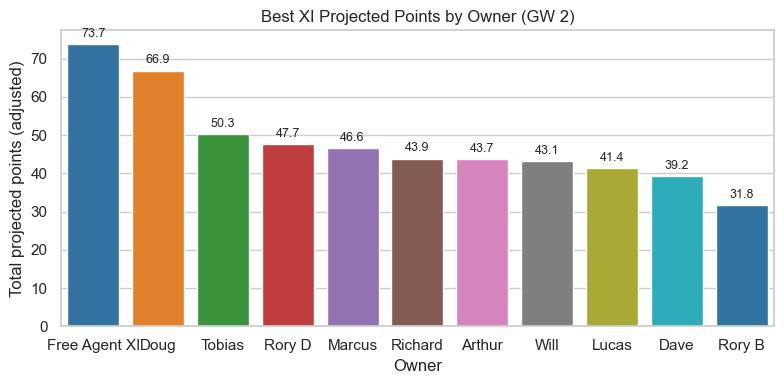

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_owner_summary = owner_summary.copy()

sns.barplot(
    data=plot_owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Shareable Plots

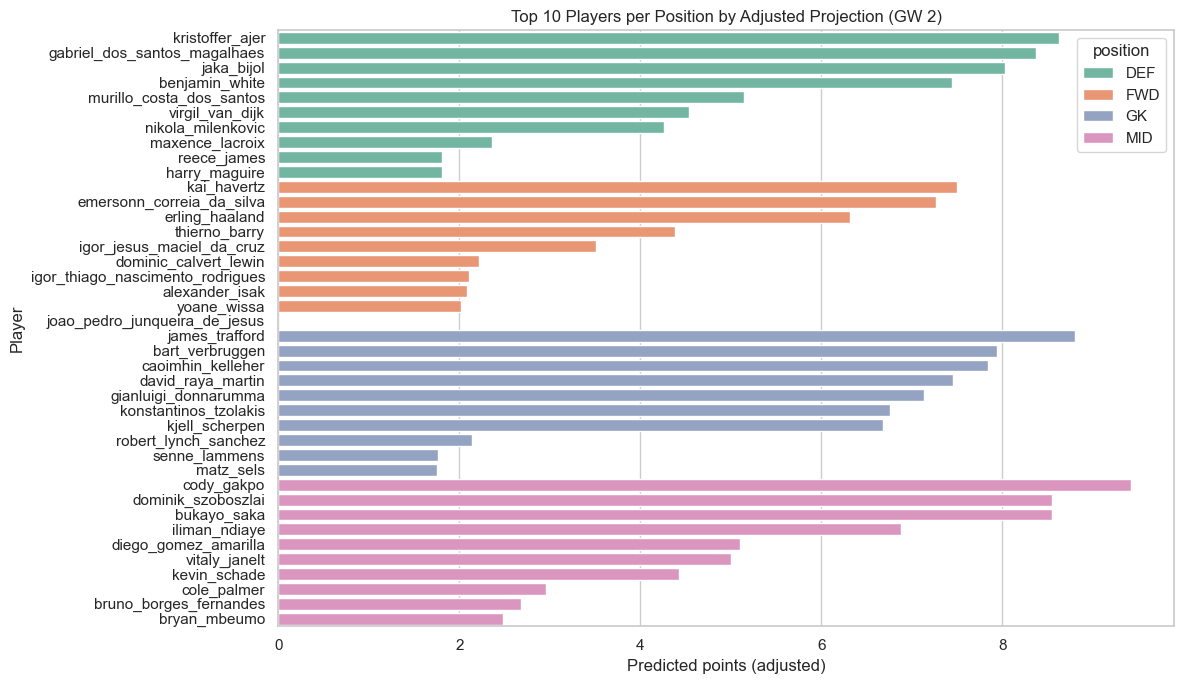

In [14]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

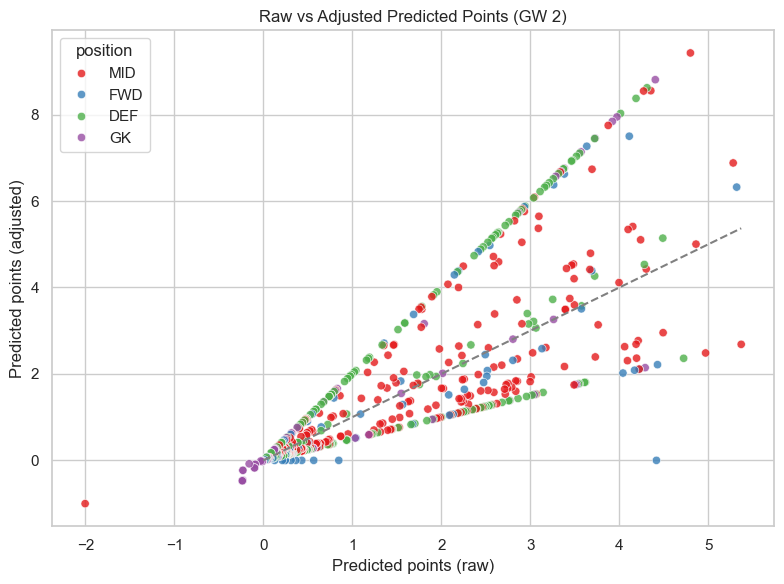

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

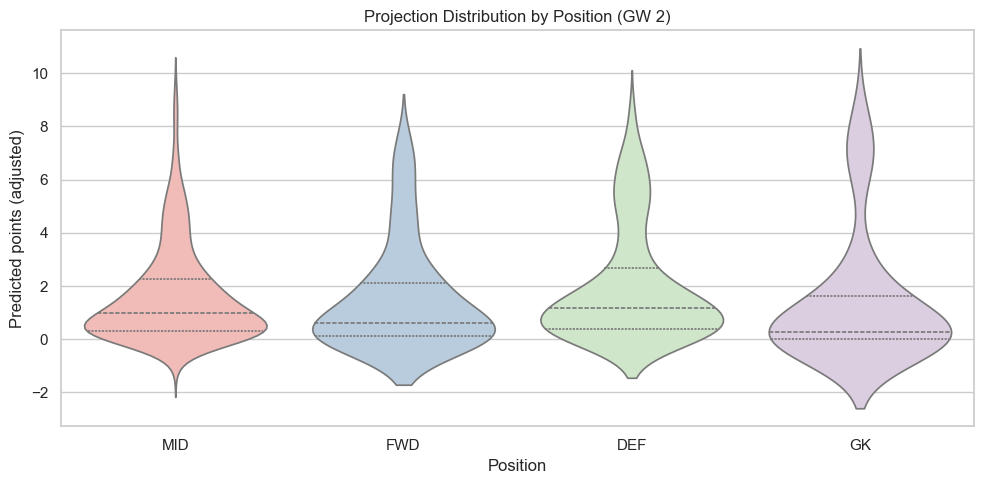

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

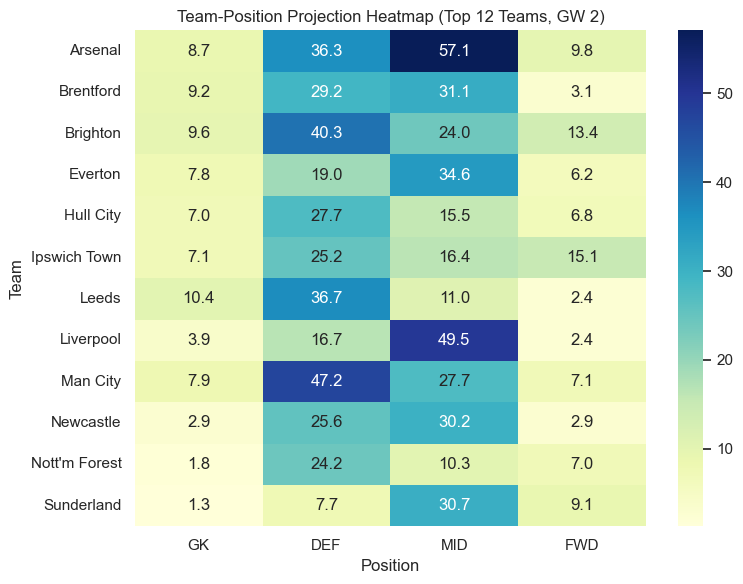

In [17]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [18]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj',
              'predicted_points_adj_3gw', 'predicted_points_adj_6gw', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,predicted_points_adj_3gw,predicted_points_adj_6gw,fixture_diff_index
0,bruno_borges_fernandes,MID,Man Utd,Lucas,5.368768,2.684384,2.684384,3.198716,0.500000
1,erling_haaland,FWD,Man City,Rory D,5.317992,6.321838,4.654225,4.494880,1.188764
2,iliman_ndiaye,MID,Everton,Lucas,5.278661,6.881088,7.540832,6.545776,1.303567
3,bryan_mbeumo,MID,Man Utd,Rory B,4.969009,2.484505,2.484505,2.959566,0.500000
4,vitaly_janelt,MID,Brentford,Free Agent,4.860854,5.003238,7.255066,7.650973,1.029292
5,cody_gakpo,MID,Liverpool,Rory D,4.798142,9.425770,8.887542,7.174225,1.964463
6,maxence_lacroix,DEF,Chelsea,Rory D,4.722225,2.361113,2.329211,3.150384,0.500000
7,cole_palmer,MID,Chelsea,Richard,4.491364,2.953942,3.435396,4.294353,0.657694
8,murillo_costa_dos_santos,DEF,Nott'm Forest,Richard,4.488142,5.141122,7.509192,7.130582,1.145490
9,dominic_calvert_lewin,FWD,Leeds,Arthur,4.428544,2.214272,1.467619,1.907689,0.500000


In [19]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [20]:
import re
import sys
import requests

sys.path.append(str(Path('../..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('..') / 'predictions'
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 37
Total merged player-GW rows: 0
Skipped GWs: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


""


In [21]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

No backtest rows available. Check BACKTEST_YEAR and prediction files.


In [22]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

No backtest rows available. Skipping GW metric plots.


### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

In [23]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)

No backtest rows available. Skipping corr_adj plot.
